<heading style="color: black; font-size: 29px; line-height: 1.4; font-family: 'Times New Roman', Times, serif;">
Example 2: Structured Fibres<br>
</heading>
<div style="color: black; font-size: 18px; line-height: 1.4; font-family: 'Times New Roman', Times, serif;">
This notebook shows how to add cylinders into a fibre, visualise internal structure and additional metrics.
</div>


In [29]:
import torch
import tencyl
import matplotlib.pyplot as plt

# Incident Plane Wave
lam0    = torch.tensor(0.9          ,dtype=torch.float64)       #incident vacuum wavelength (dimensionless)
k0      = 2*torch.pi/lam0                                       #incident vacuum wavenumber
phi     = torch.tensor(0.4*torch.pi ,dtype=torch.float64)
theta   = torch.tensor(0.2*torch.pi ,dtype=torch.float64)  
delta   = torch.tensor(0.1*torch.pi ,dtype=torch.float64)       #polarisation angle

# Structure
fibre_n = torch.tensor(1.5+0.01j    ,dtype=torch.complex128)    #fibre refractive index
fibre_a = torch.tensor(2.0          ,dtype=torch.float64)       #fibre radius

fibre_1=tencyl.fibre.Fibre(k0,phi,fibre_n,fibre_a)

<div style="color: black; font-size: 18px; line-height: 1.4; font-family: 'Times New Roman', Times, serif;">
First define the cylinders coordinates and radii, the origin is centered on the fibre. <br><br>
You can then visualise your structure. 
</div>

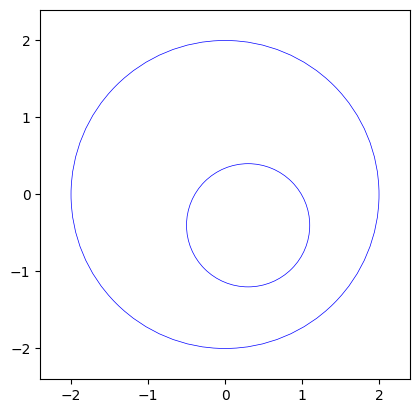

In [30]:
cyl_x = torch.tensor(0.3      ,dtype=torch.float64)                     #cylinder position
cyl_y = torch.tensor(-0.4       ,dtype=torch.float64)
cyl_a = torch.tensor(0.8          ,dtype=torch.float64)                 #cylinder radius

fig, ax = tencyl.geo.preview_structure(cyl_x, cyl_y, cyl_a, fibre_a)    #plot structure
plt.show()

<div style="color: black; font-size: 18px; line-height: 1.4; font-family: 'Times New Roman', Times, serif;">
Typically you will want more than one cylinder, which will require a 1d tensor of cylinder structure values.
</div>


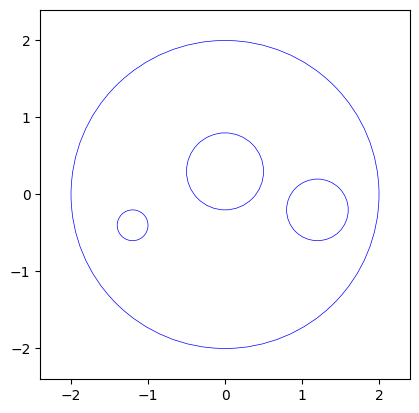

In [31]:
import matplotlib.pyplot as plt

cyl_x = torch.tensor([-1.2,     0,          1.2]      ,dtype=torch.float64)                    #cylinder position
cyl_y = torch.tensor([-0.4,     0.3,        -0.2]       ,dtype=torch.float64)
cyl_a = torch.tensor([0.2,      0.5,        0.4]          ,dtype=torch.float64)               #cylinder radius

fig, ax = tencyl.geo.preview_structure(cyl_x, cyl_y, cyl_a, fibre_a)    #plot structure
plt.show()

<div style="color: black; font-size: 18px; line-height: 1.4; font-family: 'Times New Roman', Times, serif;">
You can also randomly generate a structure.
</div>


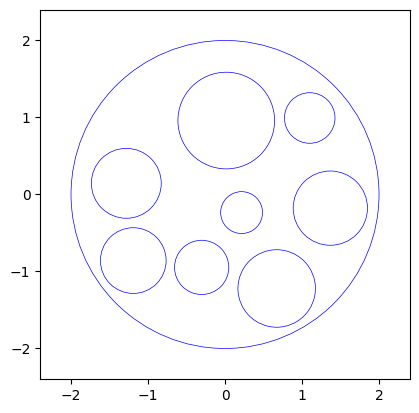

In [32]:
center=0.5
spread=0.01
pack_dist=0.1
cyl_x,cyl_y,cyl_a,cyl_count = tencyl.geo.gen_structure(center,spread,fibre_a,pack_dist)
fig, ax = tencyl.geo.preview_structure(cyl_x, cyl_y, cyl_a, fibre_a)    #plot structure
plt.show()

<div style="color: black; font-size: 18px; line-height: 1.4; font-family: 'Times New Roman', Times, serif;">
Once you have a structure you can add the cylinders to your fibre to update the fibre's scattering matrices. <br><br> 
The fibre expects the cylinders to be packaged into a single matrix, which you can create using build_cyl_matrix.
</div>

In [33]:
cyl_n=torch.tensor(1+0j,dtype=torch.complex128)                     # This may be a tensor to allow for cylinders of many different refractive indices.
cyl_matrix=tencyl.geo.build_cyl_matrix(cyl_x,cyl_y,cyl_a,cyl_n)     # 5th optional argument allows you to specify a tensor of truncation, 

fibre_1.add_cylinders(cyl_matrix)

<div style="color: black; font-size: 18px; line-height: 1.4; font-family: 'Times New Roman', Times, serif;">
We can again calculate the scattering cross section, now for a range of theta values as the structure is no longer invariant under this rotation.
</div>

In [34]:
theta_vals=torch.linspace(0.0*torch.pi,2.0*torch.pi,300)
sigma_sca,sigma_ext=tencyl.metrics.cross_sections(fibre_1,theta_vals,delta)
sigma_sca_mean=sigma_sca.mean()
sigma_ext_mean=sigma_ext.mean()
sigma_abs_mean=sigma_ext_mean-sigma_sca_mean
print("Average scattering cross section",sigma_sca_mean)
print("Average extinction cross section",sigma_ext_mean)
print("Average absorption cross section",sigma_abs_mean)


Average scattering cross section tensor(6.9262, dtype=torch.float64)
Average extinction cross section tensor(8.1803, dtype=torch.float64)
Average absorption cross section tensor(1.2541, dtype=torch.float64)


<div style="color: black; font-size: 18px; line-height: 1.4; font-family: 'Times New Roman', Times, serif;">
There is also a function which calculates the normalised theta averaged change in power in the plane wave direction as a result of the structure.
</div>

In [27]:
forward=tencyl.metrics.forward(fibre_1)
print(forward)

AttributeError: module 'tencyl.metrics' has no attribute 'forward'

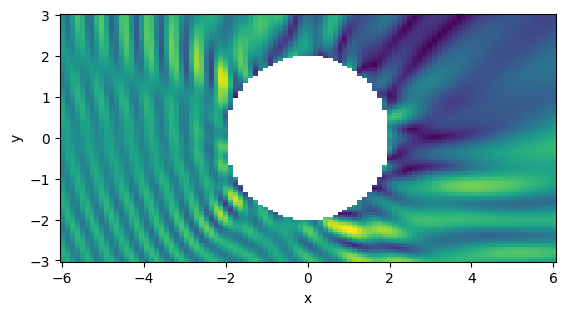

In [41]:
grid_pts=100
x=torch.linspace(-6,6,grid_pts)
y=torch.linspace(-3,3,grid_pts)
E,K=tencyl.metrics.external_field(fibre_1,theta,delta,x,y,grid_pts)

fig, ax = plt.subplots()

pcm = ax.pcolormesh(x, y, E.abs(), shading="auto")
ax.set_xlabel("x")
ax.set_ylabel("y")

ax.set_aspect("equal", adjustable="box")
plt.show()